# 03 - Model 1: LightGBM

TF-IDF -> TruncatedSVD (dense text signal) + one-hot categoricals + the hand-crafted
features from `src/features.py`, fed to LightGBM with `scale_pos_weight` for the
class imbalance.

This is the model that can use *both* halves of the data: the wording of the advert
and the metadata around it (no logo, no salary, vague location).

In [2]:
import sys
from pathlib import Path

# Make `src` importable whether this runs from notebooks/ or the project root.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config, evaluation, features, models, preprocessing

config.set_seed()
config.ensure_dirs()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

In [3]:
train, val, test = preprocessing.load_splits()

# Fit every transformer on train only, then reuse them - no refitting on val/test.
# scale_numeric=False: trees split on thresholds, so standardising numeric features
# changes nothing for LightGBM and only blurs their interpretability in importances.
X_train, y_train, artifacts = preprocessing.preprocess_data(train, scale_numeric=False)
X_val, y_val = preprocessing.preprocess_new_data(val, artifacts)
X_test, y_test = preprocessing.preprocess_new_data(test, artifacts)

print(f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")
print(f"{config.SVD_COMPONENTS} SVD text components + "
      f"{X_train.shape[1] - config.SVD_COMPONENTS - len(features.NUMERIC_FEATURES)} one-hot + "
      f"{len(features.NUMERIC_FEATURES)} hand-crafted")
X_train.iloc[:3, -8:]

X_train (12319, 424) | X_val (2640, 424) | X_test (2640, 424)
200 SVD text components + 190 one-hot + 34 hand-crafted


,has_email,has_url,has_phone,has_money,location_depth,salary_low,salary_high,salary_span
0,0.0,0.0,0.0,0.0,1.0,-1.0,-1.0,-1.0
1,0.0,1.0,1.0,0.0,3.0,-1.0,-1.0,-1.0
2,0.0,0.0,0.0,0.0,1.0,-1.0,-1.0,-1.0


In [4]:
scale_pos_weight = models.compute_scale_pos_weight(y_train)
print(f"scale_pos_weight = {scale_pos_weight:.1f} (negatives per positive)")

model = models.train_lightgbm(X_train, y_train, X_val, y_val)
print(f"stopped at {model.best_iteration_ or model.n_estimators} trees "
      f"(early stopping on validation average precision)")

scale_pos_weight = 19.5 (negatives per positive)
stopped at 212 trees (early stopping on validation average precision)


### Evaluate train and validation separately

In [5]:
proba_train = models.predict_proba(model, X_train)
proba_val = models.predict_proba(model, X_val)

train_metrics = evaluation.evaluate_predictions(y_train, proba_train)
val_metrics = evaluation.evaluate_predictions(y_val, proba_val)

print("train:", {k: round(v, 4) for k, v in train_metrics.items()})
print("val:  ", {k: round(v, 4) for k, v in val_metrics.items()})
print(f"\nAP gap (train - val): "
      f"{train_metrics['average_precision'] - val_metrics['average_precision']:.3f}")

train: {'average_precision': np.float64(1.0), 'roc_auc': np.float64(1.0), 'f1': 1.0, 'precision': 1.0, 'recall': 1.0, 'accuracy': 1.0, 'threshold': 0.5}
val:   {'average_precision': np.float64(0.9202), 'roc_auc': np.float64(0.9916), 'f1': 0.8326, 'precision': 0.9238, 'recall': 0.7578, 'accuracy': 0.9852, 'threshold': 0.5}

AP gap (train - val): 0.080


### Tune the threshold on validation, then freeze it

In [7]:
best_threshold, best_f2 = evaluation.tune_threshold(y_val, proba_val, beta=2.0)
print(f"best F2 threshold: {best_threshold:.3f} (F2={best_f2:.3f})")

# F1 shown for context; we freeze the F2 threshold to match every other model
# (baseline was frozen on F2 too), so the precision/recall columns stay comparable.
f1_threshold, best_f1 = evaluation.tune_threshold(y_val, proba_val, beta=1.0)
print(f"best F1 threshold: {f1_threshold:.3f} (F1={best_f1:.3f})")

precision_threshold, recall_at_90 = evaluation.threshold_for_precision(y_val, proba_val, 0.9)
print(f"90% precision at threshold {precision_threshold:.3f} -> catches {recall_at_90:.1%} of scams")

val_tuned = evaluation.evaluate_predictions(y_val, proba_val, threshold=best_threshold)
evaluation.log_experiment("lightgbm_tfidf_svd_meta", val_tuned, split="val",
                          notes=f"SVD={config.SVD_COMPONENTS}, spw={scale_pos_weight:.1f}, F2-tuned")
print("\nval @tuned:", {k: round(v, 3) for k, v in val_tuned.items()})

best F2 threshold: 0.095 (F2=0.870)
best F1 threshold: 0.384 (F1=0.838)
90% precision at threshold 0.430 -> catches 78.1% of scams

val @tuned: {'average_precision': np.float64(0.92), 'roc_auc': np.float64(0.992), 'f1': 0.803, 'precision': 0.711, 'recall': 0.922, 'accuracy': 0.978, 'threshold': 0.095}


In [10]:
proba_test = models.predict_proba(model, X_test)
test_metrics = evaluation.evaluate_predictions(y_test, proba_test, threshold=best_threshold)
print("test:", {k: round(v, 4) for k, v in test_metrics.items()})

evaluation.log_experiment("lightgbm_tfidf_svd_meta", test_metrics, split="test",
                          notes="threshold frozen from val")
models.save_test_predictions("lightgbm_tfidf_svd_meta", y_test, proba_test)

test: {'average_precision': np.float64(0.9211), 'roc_auc': np.float64(0.9918), 'f1': 0.7904, 'precision': 0.7055, 'recall': 0.8984, 'accuracy': 0.9769, 'threshold': 0.0948}
Saved /content/Fake_Job_Postings_Detection/models/predictions_lightgbm_tfidf_svd_meta_test.csv


PosixPath('/content/Fake_Job_Postings_Detection/models/predictions_lightgbm_tfidf_svd_meta_test.csv')

## Curves and confusion matrix

Saved /content/Fake_Job_Postings_Detection/reports/figures/10_lgbm_pr_curve.png


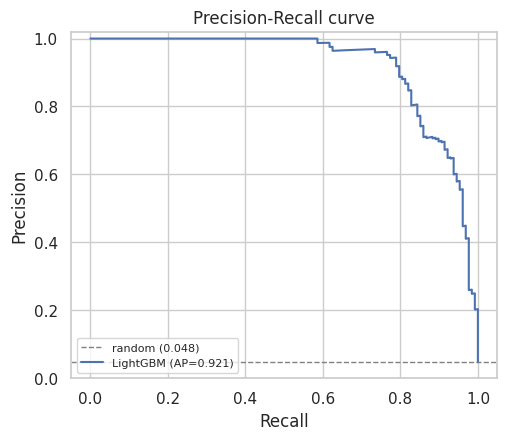

Saved /content/Fake_Job_Postings_Detection/reports/figures/11_lgbm_roc_curve.png


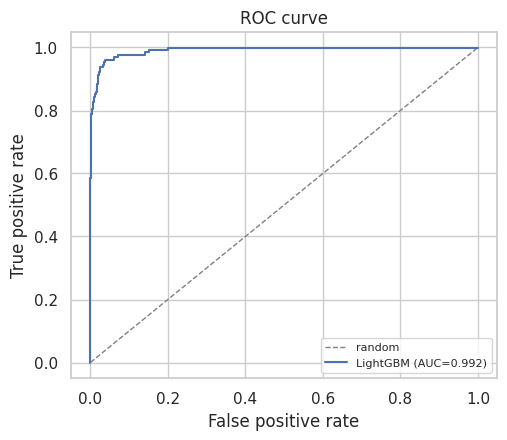

Saved /content/Fake_Job_Postings_Detection/reports/figures/12_lgbm_confusion_matrix.png


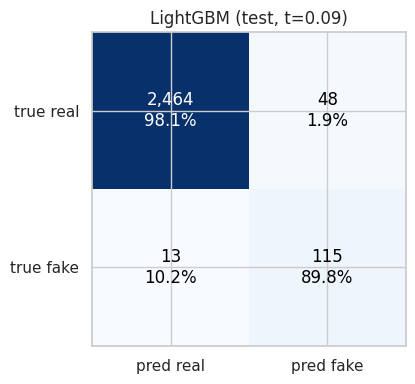

In [11]:
evaluation.plot_pr_curve(y_test, proba_test, label="LightGBM", save_as="10_lgbm_pr_curve.png")
plt.show()
evaluation.plot_roc_curve(y_test, proba_test, label="LightGBM", save_as="11_lgbm_roc_curve.png")
plt.show()
evaluation.plot_confusion_matrix(y_test, (proba_test >= best_threshold).astype(int),
                                 title=f"LightGBM (test, t={best_threshold:.2f})",
                                 save_as="12_lgbm_confusion_matrix.png")
plt.show()

## Feature importance

`svd_*` are compressed text directions and are not individually interpretable - what
matters is how high the *hand-crafted* features rank against them.

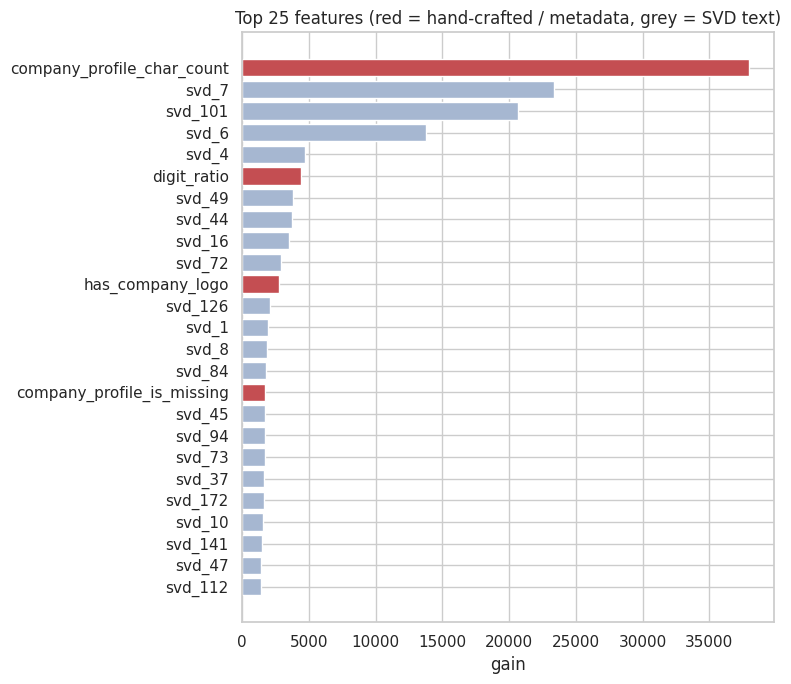

Best non-text features:
                             feature         gain
          company_profile_char_count 37939.118860
                         digit_ratio  4396.125106
                    has_company_logo  2735.720360
          company_profile_is_missing  1733.070213
          company_profile_word_count  1160.254746
                          caps_ratio   941.877960
required_education_Bachelor_s_Degree   868.914647
                          country_GR   578.631498
       industry_Education_Management   475.651009
              description_word_count   433.996733
             requirements_char_count   429.489060
               department_is_missing   380.910010


In [13]:
importance = models.feature_importance_frame(model)
top = importance.head(25).sort_values("gain")

fig, ax = plt.subplots(figsize=(8, 7))
colours = ["#c44e52" if not f.startswith("svd_") else "#a6b7d1" for f in top["feature"]]
ax.barh(top["feature"], top["gain"], color=colours)
ax.set_xlabel("gain")
ax.set_title("Top 25 features (red = hand-crafted / metadata, grey = SVD text)")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "13_lgbm_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

engineered = importance[~importance["feature"].str.startswith("svd_")]
print("Best non-text features:")
print(engineered.head(12).to_string(index=False))

**What the model learned matches the EDA.** The strongest feature by a wide
margin is `company_profile_char_count`, well ahead of any single SVD direction,
and it sits alongside `company_profile_is_missing` and `company_profile_word_count` near the top. This is the missingness signal from the EDA made quantitative: the best predictor of fraud is *how little the advert says about the company*, not any single word.

`digit_ratio` and `has_company_logo` follow, with `caps_ratio` close behind - the surface markers of a scam (dollar amounts, a missing logo, ALL-CAPS urgency), echoing the `has_money` and no-logo gaps from the EDA.

The `svd_*` text directions are individually weaker but numerous: wording carries real signal, just spread thin across many components. That split - concentrated metadata vs. diffuse text - is why LightGBM only edged past the bag-of-words baseline instead of beating it outright.

### SHAP (optional)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_1170/3061070691.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample, max_display=20, show=False)


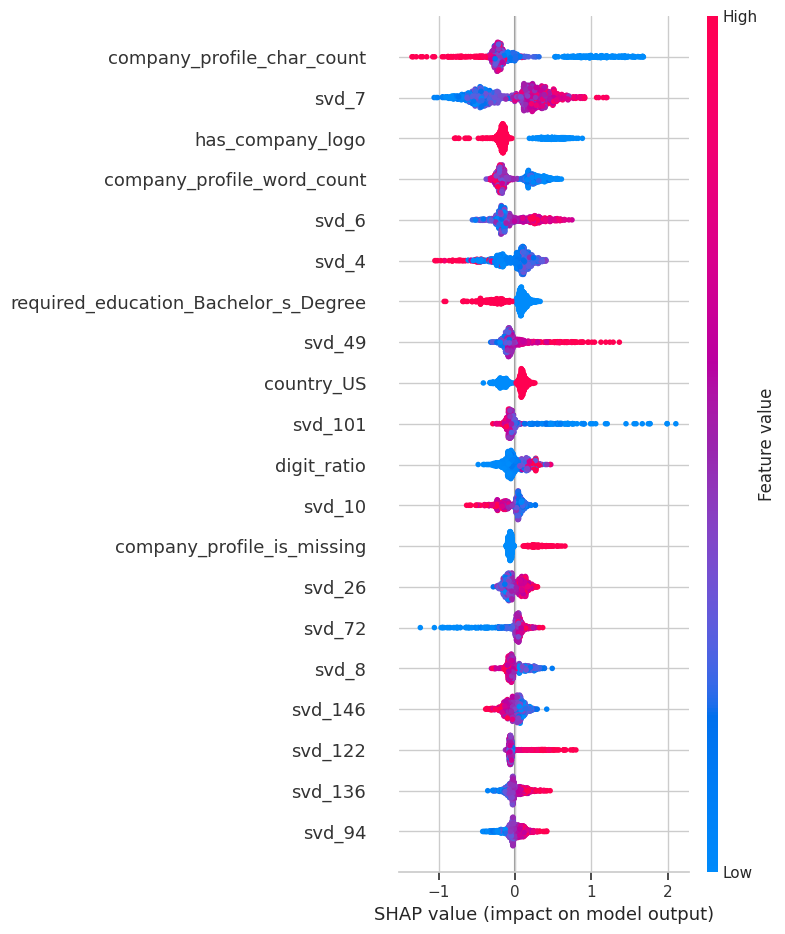

In [14]:
try:
    import shap
except ImportError:
    print("shap not installed - skipping (pip install shap). Gain importances above cover the basics.")
else:
    sample = X_val.sample(n=min(1000, len(X_val)), random_state=config.SEED)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(sample)
    # Binary LightGBM may return one array or a list of two; take the positive class.
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    shap.summary_plot(shap_values, sample, max_display=20, show=False)
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "14_lgbm_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

## Error analysis: which scams slip through?

False negatives are the expensive mistakes. Read a few and look for the pattern -
typically they are the well-written fakes that filled in every field.

In [15]:
# top_n=len(test) returns every false negative; the print loop shows the worst few.
false_negatives = evaluation.get_errors(test, y_test, proba_test, best_threshold,
                                        kind="false_negatives", top_n=len(test))
print(f"{len(false_negatives)} scams missed out of {int(y_test.sum())} "
      f"({len(false_negatives) / max(int(y_test.sum()), 1):.1%} of them)\n")

for _, row in false_negatives.head(5).iterrows():
    print(f"--- p(fraud)={row['predicted_proba']:.3f} | {row['title'][:70]}")
    print(f"    logo={row['has_company_logo']} questions={row['has_questions']} "
          f"profile_missing={row['company_profile_is_missing']} "
          f"words={row['full_text_word_count']}")
    print(f"    {row['description'][:220]}...\n")

13 scams missed out of 128 (10.2% of them)

--- p(fraud)=0.001 | Urgent position for SQL BI Tester
    logo=1 questions=1 profile_missing=1 words=86
    SQL BI Tester Location: Redmond, WADuration: 6+ Months This is a typical SQL database & ETL tester role that we have fulfilled in the past,...

--- p(fraud)=0.002 | CNC Programmer
    logo=0 questions=0 profile_missing=1 words=162
    2018Job Title: CNC ProgrammerRole: Project ManagerRelocation Available: YesIndustry: ManufacturingLocation: IowaTown / City: Des MoinesJob Type: Permanent full-timeJob description:We are looking for a CNC programmer who ...

--- p(fraud)=0.002 | Military Benefits Advocate
    logo=1 questions=1 profile_missing=0 words=334
    AWC WANTS YOU:We are looking for a talented and competitive Inside Telecommute Benefits Representative that thrives in a fact paced "not for profit" cycle environment. The successful candidate will play a fundamental rol...

--- p(fraud)=0.009 | Production Technician 1781
    logo=0 

In [17]:
# Compare every missed scam against every caught one - averaged over 5 rows this
# would be noise.
profile_cols = ["has_company_logo", "has_questions", "company_profile_is_missing",
                "full_text_word_count", "caps_ratio"]
caught = test.loc[(y_test == 1) & (proba_test >= best_threshold)]

comparison = pd.DataFrame({
    "missed_scams": false_negatives[profile_cols].mean(),
    "caught_scams": caught[profile_cols].mean(),
    "real_postings": test.loc[y_test == 0, profile_cols].mean(),
})
print("Missed scams look as suspicious as caught ones on metadata - the text is what fools the model:")
print(comparison.round(3).to_string())

Missed scams look as suspicious as caught ones on metadata - the text is what fools the model:
                            missed_scams  caught_scams  real_postings
has_company_logo                   0.308         0.287          0.821
has_questions                      0.538         0.357          0.510
company_profile_is_missing         0.769         0.704          0.169
full_text_word_count             269.308       286.930        380.028
caps_ratio                         0.057         0.064          0.048


### False positives - the real postings we would annoy

In [18]:
false_positives = evaluation.get_errors(test, y_test, proba_test, best_threshold,
                                        kind="false_positives", top_n=3)
for _, row in false_positives.iterrows():
    print(f"--- p(fraud)={row['predicted_proba']:.3f} | {row['title'][:70]}")
    print(f"    logo={row['has_company_logo']} profile_missing={row['company_profile_is_missing']}")
    print(f"    {row['description'][:200]}...\n")

--- p(fraud)=0.954 | Part-Time Administrative/Data Entry I
    logo=0 profile_missing=1
    As Part Time Administrative Assistant/ Data Entry I you will be responsible for:- Reporting directly to Account Managers- Professional phone communication; phones, fax, email- Responding to and resolv...

--- p(fraud)=0.911 | Office PA/Receptionist
    logo=0 profile_missing=1
    Job Duties Include: • Deliveries and pick ups as needed (must have reliable transportation) • Scanning Documents • Answering multi line phone system • Placing orders for office supplies • Greeting cli...

--- p(fraud)=0.866 | Data Entry/Customer Service Rep
    logo=0 profile_missing=1
    As a Data Entry/Customer Service Representative you will be responsible for simultaneously managing inbound and outbound phone calls and processing customer payments. Being able to multi-task is very ...



## Save the model and the fitted transformers

In [19]:
models.save_model(model, "lightgbm_tfidf_svd_meta")
# The artifacts must travel with the model - without them new data cannot be
# transformed the same way.
models.save_model(artifacts, "lightgbm_artifacts")
print(f"\nfrozen decision threshold: {best_threshold:.4f}")
evaluation.load_experiments()

Saved /content/Fake_Job_Postings_Detection/models/lightgbm_tfidf_svd_meta.joblib
Saved /content/Fake_Job_Postings_Detection/models/lightgbm_artifacts.joblib

frozen decision threshold: 0.0948


,timestamp,model,split,average_precision,roc_auc,f1,precision,recall,accuracy,threshold,notes
0,2026-08-04T17:00:52,lightgbm_tfidf_svd_meta,val,0.920166,0.991565,0.802721,0.710843,0.921875,0.978030,0.094780,"SVD=200, spw=19.5, F2-tuned"
1,2026-08-03T04:08:19,baseline_tfidf_logreg,val,0.909173,0.991531,0.811388,0.745098,0.890625,0.979924,0.448105,"threshold tuned on val (F2), C=1.0"
2,2026-08-03T03:49:03,baseline_most_frequent,val,0.048485,0.500000,0.000000,0.000000,0.000000,0.951515,0.500000,always predicts the majority class


## Conclusions

**LightGBM edges past the baseline, but only just** - test PR-AUC 0.921 vs. 0.909
(+0.012). The metadata (missing profile, no logo, digit ratio) adds signal, but the
text is fed lossy-compressed (200 SVD components vs. the baseline's ~50k sparse
features), so the two roughly cancel. Feature importance confirms the EDA: the single
strongest predictor is `company_profile_char_count` - *how little the advert says
about the company* - ahead of any text direction.

**Errors are systematic.** At the F2 threshold (0.095) the model catches 90% of scams
for 48 false alarms (1.9% of real posts). Missed scams carry suspicious metadata just
like caught ones - what saves them is text that reads like a genuine technical role
(fakes with screening questions slip through more: 54% vs 36%). False positives are
real low-profile admin / data-entry posts with blank company profiles - the exact
pattern the model learned as fraud.

**Practical takeaway.** The recall-90% point suits a "flag for human review" queue,
not an auto-block, which would penalise small legitimate employers. LightGBM leans on
metadata a determined scammer can fake, so the hardest cases - fakes that read like
real technical roles - still slip through; a text-first model (next: DistilBERT) may
catch what metadata misses.

Next: `04_sentence_transformers.ipynb`.